In [1]:
# ============================================================
# CELL 1 — Run every time: mount drive and imports
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM
from collections import defaultdict

# Confirm GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Define all paths — change LLM_project if you named your folder differently
BASE = "/content/drive/MyDrive/Colab Notebooks/data/llms_final_project"
DATA_PATH  = f"{BASE}/data/ja_gsd-ud-train.conllu"
MODEL_DIR  = f"{BASE}/models"
RESULTS    = f"{BASE}/results"

print("Drive mounted. Paths set.")
print(f"Data file exists: {os.path.exists(DATA_PATH)}")

Mounted at /content/drive
Using device: cuda
Drive mounted. Paths set.
Data file exists: True


In [ ]:
# ============================================================
# CELL 2 — Run ONCE only: download models and save to Drive
# Run this once, then never again — loads from Drive after this
# ============================================================

os.makedirs(f"{MODEL_DIR}/small", exist_ok=True)
os.makedirs(f"{MODEL_DIR}/medium", exist_ok=True)
os.makedirs(f"{MODEL_DIR}/large", exist_ok=True)

MODEL_NAMES = {
    "small":  "rinna/japanese-gpt2-medium",  # ~340M
    "medium": "rinna/japanese-gpt-1b",        # ~1.3B
    "large":  "cyberagent/open-calm-3b",      # ~3B
}

for label, model_name in MODEL_NAMES.items():
    save_path = f"{MODEL_DIR}/{label}"

    # Check if folder actually has model files, not just exists
    already_saved = os.path.exists(save_path) and len(os.listdir(save_path)) > 0

    if already_saved:
        print(f"[{label}] Already saved at {save_path}, skipping.")
        continue

    print(f"[{label}] Downloading {model_name} ...")
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    model     = AutoModelForCausalLM.from_pretrained(model_name)

    print(f"[{label}] Saving to {save_path} ...")
    tokenizer.save_pretrained(save_path)
    model.save_pretrained(save_path)
    print(f"[{label}] Done.")

print("\nAll models saved to Drive.")

[small] Already saved at /content/drive/MyDrive/Colab Notebooks/data/llms_final_project/models/small, skipping.
[medium] Already saved at /content/drive/MyDrive/Colab Notebooks/data/llms_final_project/models/medium, skipping.
[large] Already saved at /content/drive/MyDrive/Colab Notebooks/data/llms_final_project/models/large, skipping.

All models saved to Drive.


In [2]:
# CELL 2 (large model) — skip saving to Drive, use HF cache instead
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "cyberagent/open-calm-3b"

print("Loading large model from HuggingFace (cached after first run)...")
tokenizer_large = AutoTokenizer.from_pretrained(model_name, use_fast=False)
model_large = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
print("Done.")

Loading large model from HuggingFace (cached after first run)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/323 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Done.


In [3]:
# ============================================================
# CELL 3 — Run every time: load models
# small + medium from Drive, large from HF cache
# ============================================================

MODEL_LABELS = ["small", "medium"]

tokenizers = {}
models     = {}

# Load small and medium from Drive as before
for label in MODEL_LABELS:
    save_path = f"{MODEL_DIR}/{label}"
    print(f"Loading [{label}] from {save_path} ...")

    tokenizers[label] = AutoTokenizer.from_pretrained(save_path, use_fast=False)
    models[label]     = AutoModelForCausalLM.from_pretrained(
                            save_path,
                            torch_dtype=torch.float16
                        ).to(device)
    models[label].eval()
    print(f"[{label}] loaded.")

# Load large from HF cache (downloaded fresh each session)
print("Loading [large] from HuggingFace cache ...")
tokenizers["large"] = AutoTokenizer.from_pretrained(
                          "cyberagent/open-calm-3b",
                          use_fast=False
                      )
models["large"]     = AutoModelForCausalLM.from_pretrained(
                          "cyberagent/open-calm-3b",
                          torch_dtype=torch.float16,
                          device_map="auto"
                      )
models["large"].eval()
print("[large] loaded.")

print("\nAll models ready.")

Loading [small] from /content/drive/MyDrive/Colab Notebooks/data/llms_final_project/models/small ...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

[small] loaded.
Loading [medium] from /content/drive/MyDrive/Colab Notebooks/data/llms_final_project/models/medium ...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

[medium] loaded.
Loading [large] from HuggingFace cache ...


Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

[large] loaded.

All models ready.


In [4]:
# ============================================================
# CELL 4 — Run every time: parse the corpus (all three splits)
# ============================================================

def parse_conllu(filepath):
    sentences = []
    tokens, sent_id, text = [], "", ""
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith("# sent_id"):
                sent_id = line.split("=", 1)[-1].strip()
            elif line.startswith("# text"):
                text = line.split("=", 1)[-1].strip()
            elif line == "":
                if tokens:
                    sentences.append({"sent_id": sent_id,
                                      "text":    text,
                                      "tokens":  tokens})
                tokens, sent_id, text = [], "", []
            elif not line.startswith("#"):
                parts = line.split("\t")
                if len(parts) >= 10 and "-" not in parts[0] and "." not in parts[0]:
                    tokens.append({
                        "idx":     int(parts[0]),
                        "surface": parts[1],
                        "lemma":   parts[2],
                        "upos":    parts[3],
                        "xpos":    parts[4],
                        "head":    int(parts[6]) if parts[6] != "_" else 0,
                        "deprel":  parts[7],
                        "misc":    parts[9],
                    })
    if tokens:
        sentences.append({"sent_id": sent_id, "text": text, "tokens": tokens})
    return sentences

# Load all three splits
DATA_DIR = f"{BASE}/data"
all_sentences = []
for fname in ["ja_gsd-ud-train.conllu",
              "ja_gsd-ud-dev.conllu",
              "ja_gsd-ud-test.conllu"]:
    fpath = os.path.join(DATA_DIR, fname)
    sents = parse_conllu(fpath)
    all_sentences.extend(sents)
    print(f"Loaded {len(sents)} sentences from {fname}")

sentences = all_sentences
print(f"\nTotal sentences: {len(sentences)}")

Loaded 7050 sentences from ja_gsd-ud-train.conllu
Loaded 507 sentences from ja_gsd-ud-dev.conllu
Loaded 543 sentences from ja_gsd-ud-test.conllu

Total sentences: 8100


In [5]:
# ============================================================
# CELL 5 — Run every time: extract distance metric
# ============================================================

def get_bunsetsu_distance(tokens):
    """
    Returns (distance, root_idx, arg_idx) or None if sentence
    doesn't meet criteria (no VERB root or no case-marked argument).
    """
    # Find root
    root = next((t for t in tokens if t["deprel"] == "root"
                 and t["upos"] == "VERB"), None)
    if root is None:
        return None

    # Find tokens whose case particle is が or を
    case_marked = []
    for t in tokens:
        children = [c for c in tokens
                    if c["head"] == t["idx"]
                    and c["deprel"] == "case"
                    and c["surface"] in ("が", "を")]
        if children:
            case_marked.append(t)

    if not case_marked:
        return None

    # First case-marked argument (earliest in sentence)
    first_arg = min(case_marked, key=lambda t: t["idx"])

    # Only keep sentences where argument precedes root (normal Japanese order)
    if first_arg["idx"] >= root["idx"]:
        return None

    # Count bunsetsu heads between argument and root
    def is_bunsetsu_head(t):
        return ("BunsetuPositionType=SEM_HEAD" in t["misc"] or
                "BunsetuPositionType=SYN_HEAD" in t["misc"])

    bunsetsu_heads_between = [
        t for t in tokens
        if first_arg["idx"] <= t["idx"] <= root["idx"]
        and is_bunsetsu_head(t)
    ]

    distance = len(bunsetsu_heads_between)
    return distance, root, first_arg

# Build filtered dataset
records = []
for s in sentences:
    result = get_bunsetsu_distance(s["tokens"])
    if result is None:
        continue
    distance, root, first_arg = result
    records.append({
        "sent_id":      s["sent_id"],
        "text":         s["text"],
        "distance":     distance,
        "root_lemma":   root["lemma"],
        "root_surface": root["surface"],
        "root_idx":     root["idx"],
        "n_tokens":     len(s["tokens"]),
    })

df = pd.DataFrame(records)
print(f"Sentences after filtering: {len(df)}")
print(df[["sent_id", "distance", "n_tokens", "root_lemma", "root_surface"]].head(10))

Sentences after filtering: 3798
     sent_id  distance  n_tokens root_lemma root_surface
0   train-s3        18        31         攻撃           攻撃
1   train-s4         8        23         成る           なっ
2   train-s7        29        45         成る           なる
3   train-s9         5        13        与える          与える
4  train-s14         2        17         持つ           もて
5  train-s15         4        33         思う           思っ
6  train-s17        19        40         開始           開始
7  train-s20        21        54         転向           転向
8  train-s29        10        49         停車           停車
9  train-s33        21        59         批判           批判


In [6]:
# ============================================================
# CELL 6 (revised) — Surprisal extraction via character position
# ============================================================

import torch

def get_verb_surprisal(text, root_surface, tokenizer, model, device):
    """
    Finds the verb by its character offset in the original text,
    maps to token positions, and sums surprisal over those tokens.
    """
    char_pos = text.rfind(root_surface)
    if char_pos == -1:
        return None

    encoded = tokenizer(
        text,
        return_tensors="pt",
        return_offsets_mapping=True
    )

    if "offset_mapping" not in encoded:
        return None

    offset_mapping = encoded["offset_mapping"][0].tolist()
    input_ids = encoded["input_ids"].to(device)

    verb_start = char_pos
    verb_end   = char_pos + len(root_surface)

    verb_token_indices = []
    for idx, (start, end) in enumerate(offset_mapping):
        if start == 0 and end == 0:
            continue
        if start < verb_end and end > verb_start:
            verb_token_indices.append(idx)

    if not verb_token_indices:
        return None

    with torch.no_grad():
        outputs = model(input_ids=input_ids)
        logits = outputs.logits[0]

    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)

    total_surprisal = 0.0
    for idx in verb_token_indices:
        if idx == 0:
            continue
        token_id = input_ids[0, idx].item()
        total_surprisal += -log_probs[idx - 1, token_id].item()

    return total_surprisal


# ---- Run extraction ----
print("Starting surprisal extraction...")
print(f"Processing {len(df)} sentences x 3 models\n")

for label in ["small", "medium", "large"]:  # large loaded from HF cache
    print(f"[{label}] Extracting surprisal...")
    surprisals = []
    none_count = 0

    tok = tokenizers[label]
    mod = models[label]

    for i, row in df.iterrows():
        val = get_verb_surprisal(
            row["text"],
            row["root_surface"],
            tok, mod, device
        )
        surprisals.append(val)
        if val is None:
            none_count += 1
        if len(surprisals) % 500 == 0:
            print(f"  [{label}] {len(surprisals)}/{len(df)} processed...")

    df[f"surprisal_{label}"] = surprisals
    print(f"  [{label}] done. Could not locate verb in {none_count} sentences.\n")

print("All surprisal extraction complete.")
print(df[["sent_id", "distance", "root_surface",
          "surprisal_small", "surprisal_medium", "surprisal_large"]].head(10))

Starting surprisal extraction...
Processing 3798 sentences x 3 models

[small] Extracting surprisal...
  [small] 500/3798 processed...
  [small] 1000/3798 processed...
  [small] 1500/3798 processed...
  [small] 2000/3798 processed...
  [small] 2500/3798 processed...
  [small] 3000/3798 processed...
  [small] 3500/3798 processed...
  [small] done. Could not locate verb in 0 sentences.

[medium] Extracting surprisal...
  [medium] 500/3798 processed...
  [medium] 1000/3798 processed...
  [medium] 1500/3798 processed...
  [medium] 2000/3798 processed...
  [medium] 2500/3798 processed...
  [medium] 3000/3798 processed...
  [medium] 3500/3798 processed...
  [medium] done. Could not locate verb in 0 sentences.

[large] Extracting surprisal...
  [large] 500/3798 processed...
  [large] 1000/3798 processed...
  [large] 1500/3798 processed...
  [large] 2000/3798 processed...
  [large] 2500/3798 processed...
  [large] 3000/3798 processed...
  [large] 3500/3798 processed...
  [large] done. Could no

In [7]:
# ============================================================
# CELL 7 — Save results to Drive
# ============================================================

df.to_csv(f"{RESULTS}/surprisal_results.csv", index=False)
print(f"Saved {len(df)} rows to {RESULTS}/surprisal_results.csv")
print(df[["sent_id", "distance", "n_tokens", "root_lemma",
           "root_surface", "surprisal_small", "surprisal_medium", "surprisal_large"]].describe())

Saved 3798 rows to /content/drive/MyDrive/Colab Notebooks/data/llms_final_project/results/surprisal_results.csv
          distance     n_tokens  surprisal_small  surprisal_medium  \
count  3798.000000  3798.000000      3798.000000       3798.000000   
mean     10.989995    29.843865         4.113352          6.945114   
std       8.954478    14.879150         2.833960          5.453571   
min       2.000000     4.000000         0.003000          0.008801   
25%       4.000000    19.000000         1.955513          2.822754   
50%       9.000000    27.000000         3.650391          5.327931   
75%      16.000000    37.000000         5.679688          9.703125   
max      74.000000   136.000000        29.146484         43.453125   

       surprisal_large  
count      3798.000000  
mean          4.290120  
std           2.902892  
min           0.004330  
25%           2.135742  
50%           3.707199  
75%           5.854492  
max          19.542969  


=== BASIC STATS ===
          distance  surprisal_small  surprisal_medium  surprisal_large
count  3798.000000      3798.000000       3798.000000      3798.000000
mean     10.989995         4.113352          6.945114         4.290120
std       8.954478         2.833960          5.453571         2.902892
min       2.000000         0.003000          0.008801         0.004330
25%       4.000000         1.955513          2.822754         2.135742
50%       9.000000         3.650391          5.327931         3.707199
75%      16.000000         5.679688          9.703125         5.854492
max      74.000000        29.146484         43.453125        19.542969

=== NULL CHECK ===
Null surprisal_small:  0
Null surprisal_medium: 0
Null surprisal_large:  0

=== DISTANCE DISTRIBUTION ===
Min distance:    2
Max distance:    74
Mean distance:   10.99
Median distance: 9.0

=== SANITY CHECK: do longer sentences have longer distances? ===
Correlation between distance and sentence length: 0.775
(Expected:

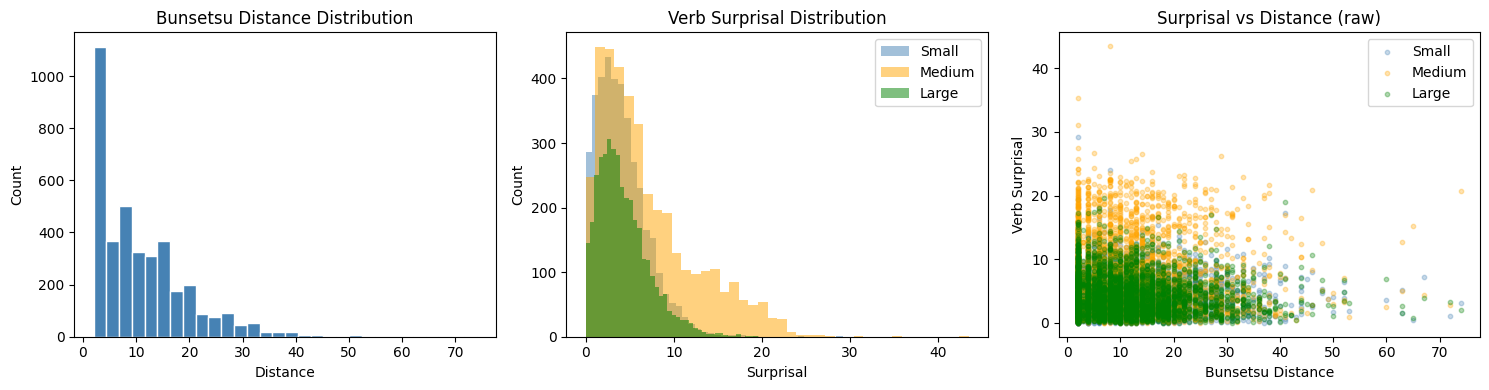

Plots saved to Drive.


In [8]:
# ============================================================
# CELL 8 — Validation checks before regression
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=== BASIC STATS ===")
print(df[["distance", "surprisal_small", "surprisal_medium", "surprisal_large"]].describe())

print("\n=== NULL CHECK ===")
print(f"Null surprisal_small:  {df['surprisal_small'].isna().sum()}")
print(f"Null surprisal_medium: {df['surprisal_medium'].isna().sum()}")
print(f"Null surprisal_large:  {df['surprisal_large'].isna().sum()}")

print("\n=== DISTANCE DISTRIBUTION ===")
print(f"Min distance:    {df['distance'].min()}")
print(f"Max distance:    {df['distance'].max()}")
print(f"Mean distance:   {df['distance'].mean():.2f}")
print(f"Median distance: {df['distance'].median()}")

print("\n=== SANITY CHECK: do longer sentences have longer distances? ===")
corr = df["distance"].corr(df["n_tokens"])
print(f"Correlation between distance and sentence length: {corr:.3f}")
print("(Expected: positive but not 1.0 — distance and length are related but distinct)")

print("\n=== SANITY CHECK: do models agree roughly? ===")
corr2 = df["surprisal_small"].corr(df["surprisal_medium"])
corr3 = df["surprisal_small"].corr(df["surprisal_large"])
corr4 = df["surprisal_medium"].corr(df["surprisal_large"])
print(f"Correlation small  vs medium: {corr2:.3f}")
print(f"Correlation small  vs large:  {corr3:.3f}")
print(f"Correlation medium vs large:  {corr4:.3f}")
print("(Expected: all positive — models should find similar sentences hard)")

print("\n=== OUTLIER CHECK ===")
for label in ["small", "medium", "large"]:
    col = f"surprisal_{label}"
    high = df[df[col] > df[col].mean() + 3*df[col].std()]
    print(f"[{label}] Extreme outliers (>3 SD above mean): {len(high)} sentences")

# ---- Plots ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Distance distribution
axes[0].hist(df["distance"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Bunsetsu Distance Distribution")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Count")

# Plot 2: Surprisal distribution for all three models
axes[1].hist(df["surprisal_small"],  bins=40, alpha=0.5, color="steelblue", label="Small")
axes[1].hist(df["surprisal_medium"], bins=40, alpha=0.5, color="orange",    label="Medium")
axes[1].hist(df["surprisal_large"],  bins=40, alpha=0.5, color="green",     label="Large")
axes[1].set_title("Verb Surprisal Distribution")
axes[1].set_xlabel("Surprisal")
axes[1].set_ylabel("Count")
axes[1].legend()

# Plot 3: Surprisal vs Distance (raw scatter)
axes[2].scatter(df["distance"], df["surprisal_small"],  alpha=0.3, s=10, color="steelblue", label="Small")
axes[2].scatter(df["distance"], df["surprisal_medium"], alpha=0.3, s=10, color="orange",    label="Medium")
axes[2].scatter(df["distance"], df["surprisal_large"],  alpha=0.3, s=10, color="green",     label="Large")
axes[2].set_title("Surprisal vs Distance (raw)")
axes[2].set_xlabel("Bunsetsu Distance")
axes[2].set_ylabel("Verb Surprisal")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS}/validation_plots.png", dpi=150)
plt.show()
print("Plots saved to Drive.")

In [9]:
# ============================================================
# CELL 9 — Controls + Regression
# ============================================================

import numpy as np
import statsmodels.formula.api as smf

# ---- Add control variables ----

freq = df["root_lemma"].value_counts()
df["verb_freq"]     = df["root_lemma"].map(freq)
df["log_verb_freq"] = np.log(df["verb_freq"])

df["log_n_tokens"] = np.log(df["n_tokens"])
df["log_distance"] = np.log(df["distance"])

print("Control variables added.")
print(df[["distance", "log_distance", "verb_freq",
          "log_verb_freq", "n_tokens", "log_n_tokens"]].describe())

# ---- Run regressions ----
print("\n=== REGRESSION RESULTS ===\n")

for label in ["small", "medium", "large"]:
    col = f"surprisal_{label}"

    data = df[["distance", "log_distance", "log_n_tokens",
                "log_verb_freq", col]].dropna()

    formula = f"{col} ~ log_distance + log_n_tokens + log_verb_freq"
    result = smf.ols(formula=formula, data=data).fit()

    print(f"--- Model: {label} ({col}) ---")
    print(f"  N sentences:        {len(data)}")
    print(f"  R-squared:          {result.rsquared:.4f}")
    print(f"  Adj. R-squared:     {result.rsquared_adj:.4f}")
    print(f"\n  Coefficients:")
    for var in ["Intercept", "log_distance", "log_n_tokens", "log_verb_freq"]:
        coef = result.params[var]
        pval = result.pvalues[var]
        stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        print(f"    {var:<20} coef={coef:>8.4f}  p={pval:.4f} {stars}")
    print()

print("Key comparison: is the log_distance coefficient different across models?")
print("A smaller (or negative) coefficient in the larger model supports our hypothesis.")

Control variables added.
          distance  log_distance    verb_freq  log_verb_freq     n_tokens  \
count  3798.000000   3798.000000  3798.000000    3798.000000  3798.000000   
mean     10.989995      2.046542    54.087941       2.397453    29.843865   
std       8.954478      0.887588    86.425268       1.893116    14.879150   
min       2.000000      0.693147     1.000000       0.000000     4.000000   
25%       4.000000      1.386294     2.000000       0.693147    19.000000   
50%       9.000000      2.197225     8.000000       2.079442    27.000000   
75%      16.000000      2.772589    83.000000       4.418841    37.000000   
max      74.000000      4.304065   266.000000       5.583496   136.000000   

       log_n_tokens  
count   3798.000000  
mean       3.278096  
std        0.494444  
min        1.386294  
25%        2.944439  
50%        3.295837  
75%        3.610918  
max        4.912655  

=== REGRESSION RESULTS ===

--- Model: small (surprisal_small) ---
  N sentences: 

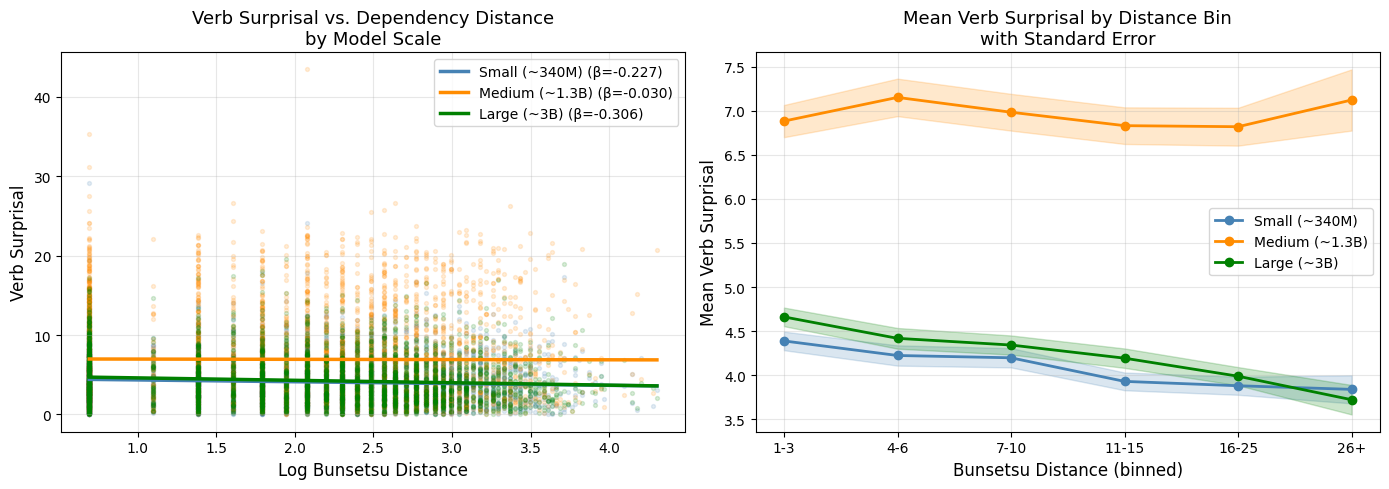

Results plot saved to Drive.


In [10]:
# ============================================================
# CELL 10 — Results visualization
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"small": "steelblue", "medium": "darkorange", "large": "green"}
labels = {"small": "Small (~340M)", "medium": "Medium (~1.3B)", "large": "Large (~3B)"}

# ---- Plot 1: Surprisal vs Distance with regression lines ----
ax = axes[0]
for label in ["small", "medium", "large"]:
    col = f"surprisal_{label}"
    ax.scatter(df["log_distance"], df[col],
               alpha=0.15, s=8, color=colors[label])

    m, b = np.polyfit(df["log_distance"], df[col], 1)
    x_range = np.linspace(df["log_distance"].min(),
                          df["log_distance"].max(), 100)
    ax.plot(x_range, m * x_range + b,
            color=colors[label], linewidth=2.5,
            label=f"{labels[label]} (β={m:.3f})")

ax.set_xlabel("Log Bunsetsu Distance", fontsize=12)
ax.set_ylabel("Verb Surprisal", fontsize=12)
ax.set_title("Verb Surprisal vs. Dependency Distance\nby Model Scale", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ---- Plot 2: Mean surprisal by distance bin ----
ax2 = axes[1]
df["distance_bin"] = pd.cut(df["distance"],
                             bins=[0, 3, 6, 10, 15, 25, 75],
                             labels=["1-3", "4-6", "7-10",
                                     "11-15", "16-25", "26+"])

for label in ["small", "medium", "large"]:
    col = f"surprisal_{label}"
    means = df.groupby("distance_bin", observed=True)[col].mean()
    sems  = df.groupby("distance_bin", observed=True)[col].sem()
    x = range(len(means))
    ax2.plot(x, means.values, marker="o", linewidth=2,
             color=colors[label], label=labels[label])
    ax2.fill_between(x,
                     means.values - sems.values,
                     means.values + sems.values,
                     alpha=0.2, color=colors[label])

ax2.set_xticks(range(len(means)))
ax2.set_xticklabels(["1-3", "4-6", "7-10", "11-15", "16-25", "26+"],
                    fontsize=10)
ax2.set_xlabel("Bunsetsu Distance (binned)", fontsize=12)
ax2.set_ylabel("Mean Verb Surprisal", fontsize=12)
ax2.set_title("Mean Verb Surprisal by Distance Bin\nwith Standard Error", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS}/main_results.png", dpi=150)
plt.show()
print("Results plot saved to Drive.")

In [11]:
# ============================================================
# CELL 11 — Summary of findings
# ============================================================

print("=" * 60)
print("SUMMARY OF FINDINGS")
print("=" * 60)

print(f"\nCorpus: UD Japanese GSD")
print(f"Sentences analyzed: {len(df)}")
print(f"Distance range: {df['distance'].min()} - {df['distance'].max()} bunsetsus")
print(f"Mean distance: {df['distance'].mean():.2f}")

print(f"\n--- Mean verb surprisal by model ---")
for label in ["small", "medium", "large"]:
    col = f"surprisal_{label}"
    print(f"  {label}: {df[col].mean():.3f} (SD={df[col].std():.3f})")

print(f"\n--- Regression: distance coefficient (controlled) ---")
import statsmodels.formula.api as smf
import numpy as np

for label in ["small", "medium", "large"]:
    col = f"surprisal_{label}"
    data = df[["log_distance", "log_n_tokens", "log_verb_freq", col]].dropna()
    result = smf.ols(f"{col} ~ log_distance + log_n_tokens + log_verb_freq",
                     data=data).fit()
    coef = result.params["log_distance"]
    pval = result.pvalues["log_distance"]
    sig  = "***" if pval < 0.001 else "**" if pval < 0.01 else \
           "*" if pval < 0.05 else "(n.s.)"
    print(f"  {label}: β={coef:.4f}, p={pval:.4f} {sig}")

print(f"\n--- Mean surprisal at shortest vs longest distances ---")
short = df[df["distance"] <= 3]
long  = df[df["distance"] >= 20]
for label in ["small", "medium", "large"]:
    col = f"surprisal_{label}"
    print(f"  {label}: short={short[col].mean():.3f}, "
          f"long={long[col].mean():.3f}, "
          f"diff={short[col].mean()-long[col].mean():.3f}")

print("\nDone.")

SUMMARY OF FINDINGS

Corpus: UD Japanese GSD
Sentences analyzed: 3798
Distance range: 2 - 74 bunsetsus
Mean distance: 10.99

--- Mean verb surprisal by model ---
  small: 4.113 (SD=2.834)
  medium: 6.945 (SD=5.454)
  large: 4.290 (SD=2.903)

--- Regression: distance coefficient (controlled) ---
  small: β=0.1450, p=0.0327 *
  medium: β=0.1808, p=0.1629 (n.s.)
  large: β=0.1930, p=0.0053 **

--- Mean surprisal at shortest vs longest distances ---
  small: short=4.387, long=3.854, diff=0.534
  medium: short=6.884, long=7.099, diff=-0.215
  large: short=4.661, long=3.916, diff=0.744

Done.


In [13]:
bins = ["1-3", "4-6", "7-10", "11-15", "16-25", "26+"]
for label in ["small", "medium", "large"]:
    col = f"surprisal_{label}"
    means = df.groupby("distance_bin", observed=True)[col].mean()
    sems  = df.groupby("distance_bin", observed=True)[col].sem()
    print(f"\n{label}:")
    for b, m, s in zip(bins, means.values, sems.values):
        print(f"  {b}: mean={m:.4f}, sem={s:.4f}")


small:
  1-3: mean=4.3875, sem=0.1053
  4-6: mean=4.2222, sem=0.1152
  7-10: mean=4.1960, sem=0.1093
  11-15: mean=3.9280, sem=0.1007
  16-25: mean=3.8785, sem=0.1028
  26+: mean=3.8374, sem=0.1592

medium:
  1-3: mean=6.8844, sem=0.1829
  4-6: mean=7.1534, sem=0.2129
  7-10: mean=6.9850, sem=0.2088
  11-15: mean=6.8325, sem=0.2079
  16-25: mean=6.8206, sem=0.2150
  26+: mean=7.1242, sem=0.3475

large:
  1-3: mean=4.6605, sem=0.1057
  4-6: mean=4.4170, sem=0.1175
  7-10: mean=4.3410, sem=0.1087
  11-15: mean=4.1916, sem=0.1102
  16-25: mean=3.9868, sem=0.1035
  26+: mean=3.7198, sem=0.1675
